# 02 · Modelagem — quem ligar primeiro

**Objetivo.** Um score que ordena os clientes de uma campanha pela chance de aderir ao depósito a prazo,
usando só informação disponível antes da ligação (conjunto F0 definido no notebook 01).

**Roteiro**
1. Dados e split treino/teste
2. Pré-processamento: escolhas e justificativas
3. Como vamos medir: métricas e por quê
4. Candidatos e validação cruzada
5. Otimização de hiperparâmetros (Optuna)
6. Calibração e ponto de operação (com predições out-of-fold)
7. Avaliação final no teste (uma única vez)
8. Ablação: quanto as variáveis proibidas inflariam as métricas
9. Modelo final salvo

In [1]:
import json
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")  # barra de progresso do Optuna fora do Jupyter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logit
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.model_selection import StratifiedKFold

from bank_marketing import plots
from bank_marketing.config import MODELS_DIR, PERIOD, REPORTS_DIR, SEED, TARGET
from bank_marketing.data import load_dataset, split_random
from bank_marketing.evaluation import gains_curve, group_auc, lift_at_k, model_metrics, paired_bootstrap, save_metrics
from bank_marketing.features import build_preprocessor
from bank_marketing.models import (
    BusinessRule,
    PeriodRateBaseline,
    group_auc_scorer,
    make_lgbm,
    make_lgbm_pooled,
    make_logistic,
    tune_lgbm,
)
from bank_marketing.plots import AQUA, BASELINE, BLUE, GRAY, INK_2, MUTED, ORANGE
from bank_marketing.train import main as train_main

plots.apply_style()
pd.set_option("display.float_format", "{:.3f}".format)
RUN_TUNING = False  # True refaz a busca do Optuna (~3-4 min); False usa o resultado salvo em models/

## 1. Dados e split treino/teste

Hold-out **estratificado 80/20** (seed 42): o teste fica trancado até a seção 7. Toda escolha (modelo,
hiperparâmetros, calibração, ponto de corte) é feita com validação cruzada **dentro do treino**.

In [2]:
df = load_dataset()
train, test = split_random(df)
y_train, y_test = train[TARGET], test[TARGET]
print(f"treino: {plots.fmt_num(len(train))} linhas ({plots.fmt_pct(y_train.mean(), 1)} de adesão) | "
      f"teste: {plots.fmt_num(len(test))} linhas ({plots.fmt_pct(y_test.mean(), 1)})")

treino: 36.168 linhas (11,7% de adesão) | teste: 9.043 linhas (11,7%)


## 2. Pré-processamento: escolhas e justificativas

Tudo dentro de `Pipeline`/`ColumnTransformer`, ajustado **só no treino** de cada fold. Assim não há
vazamento do teste para a média do `StandardScaler` nem para o vocabulário do one-hot.

| Tipo de variável | Regressão logística | LightGBM | Por quê |
|---|---|---|---|
| Nominais (`job`, `marital`, `education`, `contact`, `poutcome`) | one-hot | one-hot | sem ordem natural; `unknown` vira coluna própria |
| Binárias (`default`, `housing`, `loan`) | 0/1 (uma coluna) | one-hot | colinearidade perfeita importa na regressão, não na árvore |
| `age` | **faixas** (18–25, …, 66+) | valor bruto | a relação não é linear; faixas deixam as odds ratios legíveis |
| `balance` | log com sinal + padronização | valor bruto | cauda longa com negativos; árvores não dependem de escala |
| `pdays`, `previous` | log1p da parte positiva + padronização | valor bruto | cauda longa; `pdays = -1` vira 0 e a flag `contacted_before` carrega a informação |
| Mês do contato (`period`) | **efeito fixo** (one-hot) | **ajuste por mês** (offset no treino) | controla a época sem usá-la para ordenar clientes (ver abaixo) |

**Normalizar/padronizar?** Só na regressão logística: com regularização L2, coeficientes em escalas diferentes
seriam penalizados de forma desigual, e o otimizador converge melhor. Árvores são invariantes a transformações
monotônicas, então padronizar não muda nada.

**Como a época entra sem virar feature.**
- Na **regressão logística**, um indicador por mês absorve o nível de cada período. Assim os coeficientes das
  outras variáveis são efeitos *dentro do mês*.
- No **LightGBM**, cada linha começa o treino já no log-odds da taxa do seu mês (`init_score`). As árvores só
  aprendem o quanto cada cliente se desvia do mês em que foi ligado.
- Na hora de pontuar uma campanha nova, todos os clientes estão no mesmo mês, então essa parcela é igual para
  todos e **não muda a ordem**. Ela só volta se quisermos a probabilidade (ver seção 6).

In [3]:
linear_pre = build_preprocessor("linear", period_fe=True).fit(train)
tree_pre = build_preprocessor("tree").fit(train)
print("colunas após o pré-processamento — logística:", len(linear_pre.get_feature_names_out()),
      "| LightGBM:", len(tree_pre.get_feature_names_out()))
linear_pre.transform(train.head(3)).iloc[:, :12]

colunas após o pré-processamento — logística: 70 | LightGBM: 38


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
24001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
43409,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
20669,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000


## 3. Como vamos medir

O banco vai usar o modelo para **ordenar os clientes de uma campanha** e ligar primeiro para os do topo.
As métricas seguem essa decisão:

| Métrica | O que mede | Por que usar |
|---|---|---|
| **AUC dentro do mês** (principal) | chance de um cliente que aderiu ficar acima de um que não aderiu, **entre clientes ligados no mesmo mês** | é exatamente a pergunta de produção; não premia "adivinhar a época" |
| **Lift@20% dentro do mês** | conversão no top 20% de cada mês ÷ conversão média do mês | tradução direta para o negócio (quantas vezes melhor que ligar ao acaso) |
| ROC-AUC, Gini e KS na base toda | ordenação misturando todos os meses | padrão de mercado em bancos; comparáveis com outros trabalhos, mas também premiam distinguir épocas |
| PR-AUC | precisão × recall na classe rara | referência: 0,117 é o valor de um modelo aleatório |
| Brier + curva de calibração | qualidade da probabilidade | necessária para decisões de valor esperado (custo × benefício) |

**Acurácia fica de fora**: com 11,7% de positivos, "nunca ligar" acerta 88,3%. Também **não usamos SMOTE
nem `class_weight`**. O desbalanceamento não atrapalha a *ordenação*, e reamostrar distorce as
probabilidades de que precisamos para decidir pelo custo.

## 4. Candidatos e validação cruzada (5 folds estratificados, só no treino)

| Candidato | Papel |
|---|---|
| Dummy (taxa média) | piso: nenhum poder de ordenação |
| Só o mês | quanto da AUC "na base toda" vem só da época |
| Regra de negócio | o que um gestor faria sem modelo: pontos para sucesso anterior, sem empréstimos, saldo ≥ 0 e celular |
| Regressão logística + efeito do mês | baseline interpretável |
| LightGBM + ajuste do mês | captura não linearidades e interações; padrão vs. ajustado |

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(train, y_train))


def cross_validate_model(make):
    """Fold metrics + out-of-fold score and probability (NaN when the model has no probabilities)."""
    rows = []
    oof = pd.DataFrame(index=train.index, columns=["score", "proba"], dtype=float)
    for tr, va in folds:
        model = make().fit(train.iloc[tr], y_train.iloc[tr])
        rows.append(model_metrics(model, train.iloc[va]))
        valid = train.iloc[va]
        if hasattr(model, "decision_function"):
            oof.iloc[va, 0] = model.decision_function(valid)
        if hasattr(model, "predict_proba"):
            oof.iloc[va, 1] = model.predict_proba(valid)[:, 1]
    return pd.DataFrame(rows), oof


c_grid = [0.01, 0.1, 1.0, 10.0]
c_scores = {
    C: np.mean([group_auc_scorer(make_logistic(C).fit(train.iloc[tr], y_train.iloc[tr]), train.iloc[va], y_train.iloc[va])
                for tr, va in folds])
    for C in c_grid
}
best_C = max(c_scores, key=c_scores.get)
print("AUC dentro do mês por C:", {c: round(float(v), 4) for c, v in c_scores.items()}, "→ C =", best_C)

AUC dentro do mês por C: {0.01: 0.5934, 0.1: 0.6029, 1.0: 0.6023, 10.0: 0.6022} → C = 0.1


`C = 0,1` (regularização moderada). A partir daí a AUC dentro do mês estabiliza em ~0,60, e com `C = 0,01` o
modelo fica regularizado demais.

## 5. Otimização de hiperparâmetros (Optuna)

**Busca bayesiana (TPE)** em vez de grid: 7 hiperparâmetros contínuos ou inteiros, com interações entre eles
(taxa de aprendizado × número de árvores; folhas × mínimo por folha). O TPE concentra as tentativas nas
regiões promissoras.
- 50 tentativas, seed fixa, objetivo = **AUC dentro do mês média no CV de 5 folds**, com os mesmos folds
  usados para os outros modelos.
- Espaço de busca: `learning_rate`, `n_estimators`, `num_leaves`, `min_child_samples`, `subsample` (com
  `subsample_freq=1`, senão não tem efeito), `colsample_bytree` e `reg_lambda`.
- A regularização (mínimo por folha, subamostragem, L2) segura o overfitting de ruído dentro de cada mês.

In [5]:
best_params_path, trials_path = MODELS_DIR / "best_params.json", REPORTS_DIR / "optuna_trials.csv"
if RUN_TUNING or not best_params_path.exists():
    best_params, study = tune_lgbm(train, y_train, n_trials=50)
    best_params_path.write_text(json.dumps(best_params, indent=2) + "\n")
    study.trials_dataframe().to_csv(trials_path, index=False)
best_params = json.loads(best_params_path.read_text())
trials = pd.read_csv(trials_path)
print(json.dumps(best_params, indent=2))

{
  "learning_rate": 0.022159477430054163,
  "n_estimators": 111,
  "num_leaves": 8,
  "min_child_samples": 75,
  "subsample": 0.7960184584470696,
  "colsample_bytree": 0.6367942874131066,
  "reg_lambda": 5.588775774926665,
  "subsample_freq": 1
}


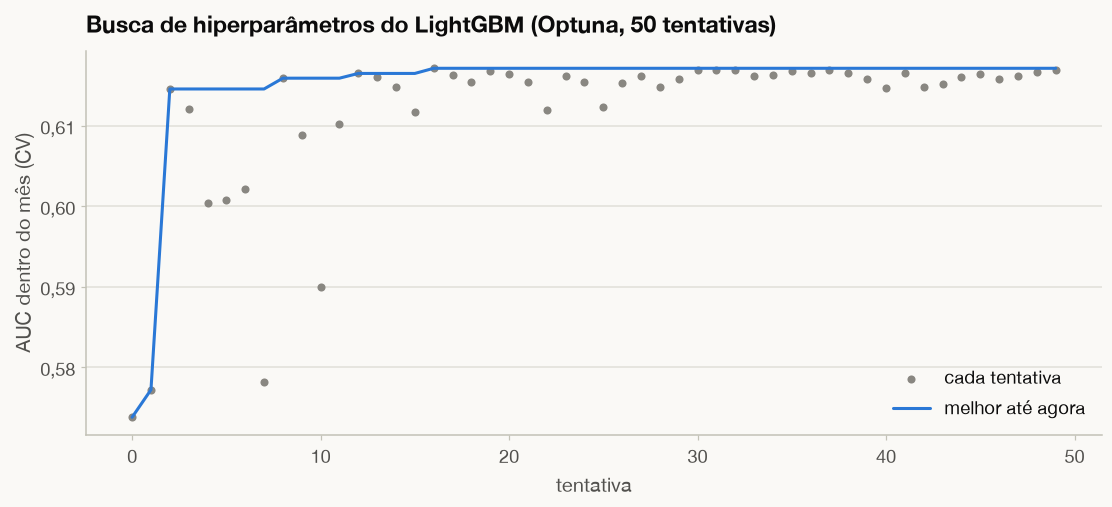

In [6]:
fig, ax = plots.new_figure(10, 4.5)
ax.scatter(trials["number"], trials["value"], color=GRAY, s=28, label="cada tentativa")
ax.plot(trials["number"], trials["value"].cummax(), color=BLUE, label="melhor até agora")
ax.set_xlabel("tentativa")
ax.set_ylabel("AUC dentro do mês (CV)")
plots.decimal_axis(ax, "y", 2)
ax.set_title("Busca de hiperparâmetros do LightGBM (Optuna, 50 tentativas)")
ax.legend(loc="lower right")
plots.save(fig, "mod_optuna")

A busca converge em ~15 tentativas para **modelos pequenos e bem regularizados**: 8 folhas, 111 árvores,
`learning_rate` 0,022 e no mínimo 75 clientes por folha. Faz sentido: o sinal do perfil dentro de um mesmo mês
é moderado, e modelos maiores passam a aprender ruído.

In [7]:
candidates = {
    "Dummy (taxa média)": lambda: DummyClassifier(strategy="prior"),
    "Só o mês": PeriodRateBaseline,
    "Regra de negócio": BusinessRule,
    "Logística + efeito do mês": lambda: make_logistic(best_C),
    "LightGBM padrão": make_lgbm,
    "LightGBM ajustado": lambda: make_lgbm(**best_params),
}
cv_folds, oof = {}, {}
for name, make in candidates.items():
    cv_folds[name], oof[name] = cross_validate_model(make)

metric_cols = ["group_auc", "lift_at_20_within_month", "capture_at_20_within_month", "roc_auc", "gini", "ks", "pr_auc", "brier"]
cv_table = pd.DataFrame({name: folds_df[metric_cols].mean() for name, folds_df in cv_folds.items()}).T
cv_std = pd.DataFrame({name: folds_df[metric_cols].std() for name, folds_df in cv_folds.items()}).T
cv_table.assign(group_auc_std=cv_std["group_auc"])

,group_auc,lift_at_20_within_month,capture_at_20_within_month,roc_auc,gini,ks,pr_auc,brier,group_auc_std
Dummy (taxa média),0.500,1.000,0.200,0.500,0.000,0.000,0.117,0.103,0.000
Só o mês,0.500,1.000,0.200,0.779,0.557,0.453,0.364,0.086,0.000
Regra de negócio,0.564,1.458,0.292,0.706,0.412,0.325,0.278,NaN,0.015
Logística + efeito do mês,0.603,1.545,0.309,0.794,0.589,0.489,0.454,0.081,0.015
LightGBM padrão,0.598,1.501,0.300,0.793,0.585,0.475,0.447,0.082,0.014
LightGBM ajustado,0.617,1.540,0.308,0.798,0.596,0.488,0.451,0.081,0.006


In [8]:
diff = cv_folds["LightGBM ajustado"]["group_auc"] - cv_folds["Logística + efeito do mês"]["group_auc"]
diff_rule = cv_folds["LightGBM ajustado"]["group_auc"] - cv_folds["Regra de negócio"]["group_auc"]
print(f"LightGBM ajustado − logística: {diff.mean():+.4f} (erro-padrão entre folds {diff.std() / np.sqrt(len(diff)):.4f}); "
      f"venceu em {(diff > 0).sum()} de {len(diff)} folds")
print(f"LightGBM ajustado − regra:     {diff_rule.mean():+.4f} (erro-padrão {diff_rule.std() / np.sqrt(len(diff_rule)):.4f})")

LightGBM ajustado − logística: +0.0142 (erro-padrão entre folds 0.0072); venceu em 4 de 5 folds
LightGBM ajustado − regra:     +0.0528 (erro-padrão 0.0086)


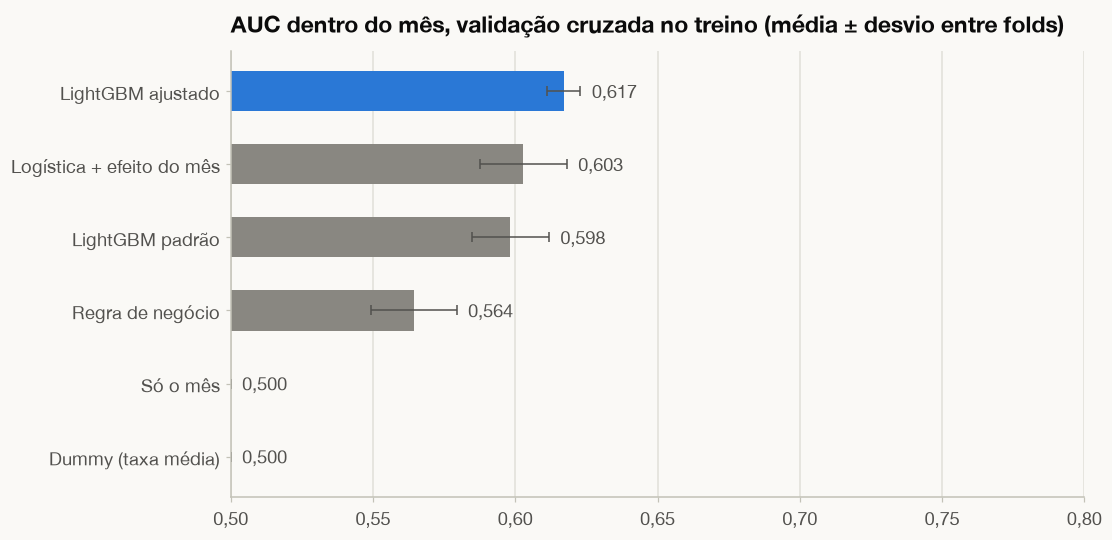

In [9]:
fig, ax = plots.new_figure(10, 4.8)
order = cv_table["group_auc"].sort_values().index
colors = [BLUE if name == "LightGBM ajustado" else GRAY for name in order]
ax.barh(order, cv_table.loc[order, "group_auc"] - 0.5, left=0.5, color=colors, height=0.55,
        xerr=cv_std.loc[order, "group_auc"], error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 3})
for i, name in enumerate(order):
    ax.text(cv_table.loc[name, "group_auc"] + cv_std.loc[name, "group_auc"] + 0.004, i,
            plots.fmt_num(cv_table.loc[name, "group_auc"], 3), va="center", fontsize=12, color=INK_2)
ax.set_xlim(0.5, max(0.8, cv_table["group_auc"].max() + 0.04))
plots.decimal_axis(ax, "x", 2)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_title("AUC dentro do mês, validação cruzada no treino (média ± desvio entre folds)")
plots.save(fig, "mod_cv_comparacao")

**Leitura da validação cruzada**
- **"Só o mês" já tem ROC-AUC de 0,78 na base toda**, sem saber nada do cliente. Boa parte da AUC que
  costuma ser reportada neste dataset é época. Dentro do mês ele vale 0,50 por construção.
- Dentro do mês:
  - regra de negócio: 0,564;
  - logística: 0,603;
  - LightGBM padrão: 0,598;
  - **LightGBM ajustado: 0,617**, com a menor variação entre folds (±0,006).
- LightGBM ajustado − logística = **+0,014** (erro-padrão 0,007; venceu em 4 de 5 folds). É um ganho pequeno
  e consistente. Contra a regra, **+0,053**.
- **Escolha: LightGBM ajustado.** É o melhor na métrica principal, o mais estável e ainda um modelo pequeno.
  A logística fica como referência interpretável.
- **Mensagem honesta:** dentro de uma mesma campanha o perfil do cliente discrimina de forma **moderada**
  (AUC ~0,62). O grosso da variação da conversão vem do contexto da época.

## 6. Calibração e ponto de operação (predições out-of-fold do treino)

O score ordena. Para decidir **quantos** clientes chamar, há duas regras:
1. **Capacidade (principal).** O call center liga para os *k%* do topo de cada campanha. Depende só da ordem,
   então não é afetada se a taxa-base mudar.
2. **Valor esperado.** Ligar se `p × V ≥ C`, ou seja, `p ≥ C/V`, onde `C` é o custo de trabalhar um cliente e
   `V` o valor de uma adesão. Aqui a probabilidade precisa estar **calibrada**.

Tudo é decidido com as predições *out-of-fold* do treino. O teste continua intocado.

Brier OOF médio: 0.0812 | maior desvio da diagonal entre os decis: 0.021


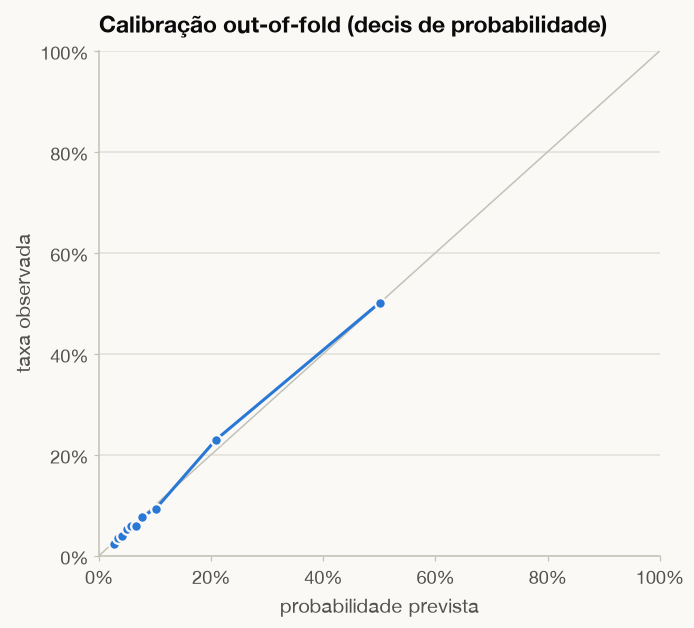

In [10]:
chosen = "LightGBM ajustado"
oof_df = train[[TARGET, PERIOD]].assign(score=oof[chosen]["score"], proba=oof[chosen]["proba"])
prob_true, prob_pred = calibration_curve(oof_df[TARGET], oof_df["proba"], n_bins=10, strategy="quantile")
brier_oof = cv_table.loc[chosen, "brier"]
calib_gap = np.abs(prob_true - prob_pred).max()
print(f"Brier OOF médio: {brier_oof:.4f} | maior desvio da diagonal entre os decis: {calib_gap:.3f}")

fig, ax = plots.new_figure(6.2, 5.6)
ax.plot([0, 1], [0, 1], color=BASELINE, linewidth=1)
ax.plot(prob_pred, prob_true, color=BLUE, marker="o", markeredgecolor=plots.SURFACE, markeredgewidth=1.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plots.percent_axis(ax, "x")
plots.percent_axis(ax, "y")
ax.set_xlabel("probabilidade prevista")
ax.set_ylabel("taxa observada")
ax.set_title("Calibração out-of-fold (decis de probabilidade)")
plots.save(fig, "mod_calibracao")

Probabilidades **bem calibradas**: o maior desvio entre a taxa prevista e a observada nos decis é de 2,1 p.p., e
o Brier fica em 0,081 contra 0,103 do Dummy. Não é preciso recalibrar (Platt/isotônica).

In [11]:
C_CLIENT, V_SUBSCRIPTION = 10.0, 100.0  # € — premissas ILUSTRATIVAS: ~2 ligações por cliente; margem de uma adesão
pct_in_month = oof_df.groupby(PERIOD)["score"].rank(pct=True, ascending=False, method="first")


def operating_point(mask):
    called = oof_df.loc[mask]
    tp = called[TARGET].sum()
    return {
        "share_called": mask.mean(),
        "precision": called[TARGET].mean(),
        "recall": tp / oof_df[TARGET].sum(),
        "resultado_por_1000_clientes_eur": 1000 * (V_SUBSCRIPTION * tp - C_CLIENT * mask.sum()) / len(oof_df),
    }


rules = {"Ligar para todos": pd.Series(True, index=oof_df.index)}
rules.update({f"Top {k:.0%} de cada mês": pct_in_month <= k for k in (0.1, 0.2, 0.3, 0.5)})
EV_RULE = f"p ≥ C/V = {C_CLIENT / V_SUBSCRIPTION:.0%}"
rules[EV_RULE] = oof_df["proba"] >= C_CLIENT / V_SUBSCRIPTION
op_table = pd.DataFrame({name: operating_point(mask) for name, mask in rules.items()}).T
op_table

,share_called,precision,recall,resultado_por_1000_clientes_eur
Ligar para todos,1.000,0.117,1.000,1698.186
Top 10% de cada mês,0.100,0.201,0.171,1003.097
Top 20% de cada mês,0.200,0.181,0.308,1611.369
Top 30% de cada mês,0.300,0.170,0.435,2088.863
Top 50% de cada mês,0.500,0.150,0.640,2486.452
p ≥ C/V = 10%,0.249,0.314,0.666,5309.113


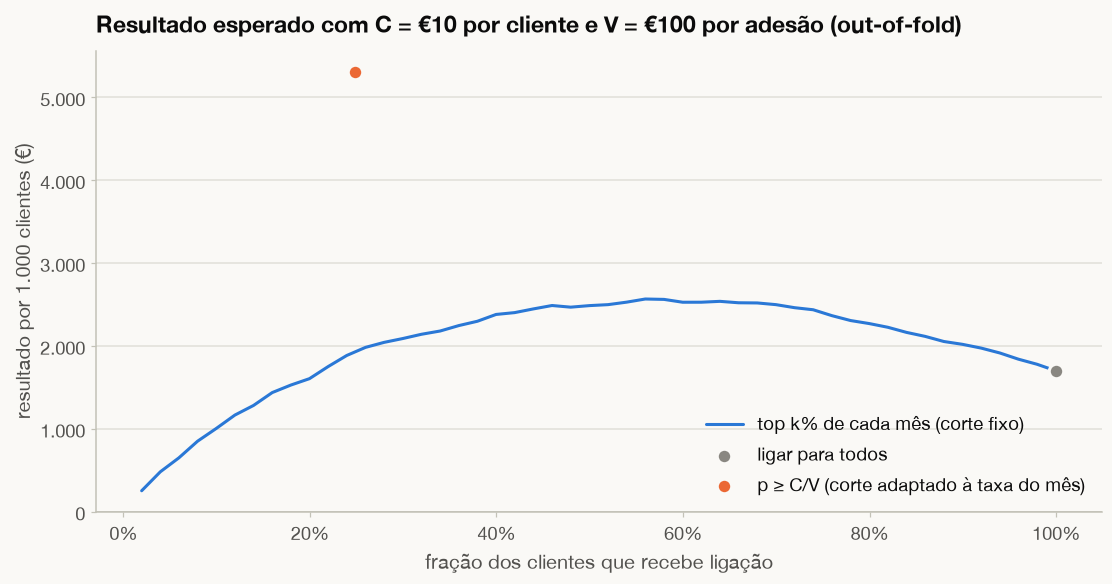

In [12]:
shares = np.linspace(0.02, 1, 50)
fixed_cut = pd.DataFrame([operating_point(pct_in_month <= k) for k in shares])
result_col = "resultado_por_1000_clientes_eur"

fig, ax = plots.new_figure(10, 5.2)
ax.plot(fixed_cut["share_called"], fixed_cut[result_col], color=BLUE, label="top k% de cada mês (corte fixo)")
for name, color, label in [("Ligar para todos", GRAY, "ligar para todos"),
                           (EV_RULE, ORANGE, "p ≥ C/V (corte adaptado à taxa do mês)")]:
    point = op_table.loc[name]
    ax.scatter(point["share_called"], point[result_col], color=color, s=90, zorder=3,
               edgecolor=plots.SURFACE, linewidth=2, label=label)
ax.axhline(0, color=BASELINE, linewidth=1)
plots.percent_axis(ax, "x")
plots.thousands_axis(ax)
ax.set_xlabel("fração dos clientes que recebe ligação")
ax.set_ylabel("resultado por 1.000 clientes (€)")
ax.set_title(f"Resultado esperado com C = €{C_CLIENT:.0f} por cliente e V = €{V_SUBSCRIPTION:.0f} por adesão (out-of-fold)")
ax.legend(loc="lower right")
plots.save(fig, "mod_lucro")

In [13]:
all_positives = oof_df[TARGET].sum()
sensitivity = {}
for ratio in (5, 10, 20):
    called = oof_df["proba"] >= 1 / ratio
    ev = 1000 * (ratio * oof_df.loc[called, TARGET].sum() - called.sum()) / len(oof_df)
    everyone = 1000 * (ratio * all_positives - len(oof_df)) / len(oof_df)
    sensitivity[f"V/C = {ratio}"] = {"limiar p*": 1 / ratio, "fração ligada": called.mean(),
                                     "resultado (unidades de C por 1.000)": ev, "ligar para todos": everyone}
pd.DataFrame(sensitivity).T

,limiar p*,fração ligada,resultado (unidades de C por 1.000),ligar para todos
V/C = 5,0.200,0.142,177.616,-415.091
V/C = 10,0.100,0.249,530.911,169.819
V/C = 20,0.050,0.641,1435.523,1339.637


In [14]:
oof_df["year"] = train["year"]
ev_by_year = {}
for year, g in oof_df.groupby("year"):
    called = g["proba"] >= C_CLIENT / V_SUBSCRIPTION
    ev_by_year[int(year)] = {
        "clientes": len(g), "fração ligada pela regra": called.mean(),
        "regra p ≥ C/V (€ por 1.000)": 1000 * (V_SUBSCRIPTION * g.loc[called, TARGET].sum() - C_CLIENT * called.sum()) / len(g),
        "ligar para todos (€ por 1.000)": 1000 * (V_SUBSCRIPTION * g[TARGET].sum() - C_CLIENT * len(g)) / len(g),
    }
pd.DataFrame(ev_by_year).T

,clientes,fração ligada pela regra,regra p ≥ C/V (€ por 1.000),ligar para todos (€ por 1.000)
2008,22142.000,0.007,154.909,-4892.060
2009,11962.000,0.566,8629.828,7054.004
2010,2064.000,1.000,41356.589,41356.589


**Quantos ligar.** Premissas ilustrativas: C = €10 por cliente trabalhado e V = €100 por adesão, logo
p* = C/V = 10%.
- Ligar para todos rende ~€1.700 por 1.000 clientes.
- O melhor corte fixo por mês chega a ~€2.570, ligando para ~56% dos clientes.
- A regra **p ≥ C/V** rende **~€5.300 ligando para só 25%**, porque adapta o corte à taxa de cada campanha.
  **Ano a ano** (tabela acima) dá para ver de onde vem o ganho:
  - em 2008, ligar para todos dava **prejuízo** (−€4,9 mil por 1.000), e a regra liga para menos de 1%;
  - em 2009, a regra rende ~22% a mais que ligar para todos;
  - em 2010, liga para todos, e o resultado é idêntico.

  O valor da regra está em **se adaptar ao clima**, não num multiplicador fixo.
- Com V/C = 5, ligar para todos dá prejuízo; a regra continua positiva.

**Ressalva importante:** aqui a taxa do mês é conhecida, porque vem de clientes do mesmo mês no treino. Em
produção ela precisa ser **estimada** (por exemplo, pela campanha anterior). O notebook 03 testa isso fora do
tempo. O corte por capacidade (top k% do score) não depende dessa estimativa.

## 7. Avaliação final no teste (uma única vez)

Os modelos são retreinados no treino inteiro e avaliados no teste, que não foi usado em nenhuma escolha.

In [15]:
fitted = {name: make().fit(train, y_train) for name, make in candidates.items()}
test_table = pd.DataFrame({name: model_metrics(model, test) for name, model in fitted.items()}).T[metric_cols]
test_table

,group_auc,lift_at_20_within_month,capture_at_20_within_month,roc_auc,gini,ks,pr_auc,brier
Dummy (taxa média),0.500,1.000,0.200,0.500,0.000,0.000,0.117,0.103
Só o mês,0.500,1.000,0.200,0.789,0.578,0.469,0.378,0.084
Regra de negócio,0.550,1.394,0.278,0.714,0.428,0.332,0.285,NaN
Logística + efeito do mês,0.585,1.516,0.302,0.802,0.605,0.492,0.470,0.079
LightGBM padrão,0.611,1.430,0.285,0.802,0.603,0.488,0.462,0.081
LightGBM ajustado,0.606,1.482,0.296,0.805,0.609,0.494,0.465,0.080


In [16]:
lgbm, logistic, rule = fitted["LightGBM ajustado"], fitted["Logística + efeito do mês"], fitted["Regra de negócio"]
months = test[PERIOD].to_numpy()
boot = {
    "LightGBM ajustado − padrão (AUC dentro do mês)": paired_bootstrap(
        y_test, lgbm.decision_function(test), fitted["LightGBM padrão"].decision_function(test), group_auc, groups=months),
    "LightGBM − logística (AUC dentro do mês)": paired_bootstrap(
        y_test, lgbm.decision_function(test), logistic.decision_function(test), group_auc, groups=months),
    "LightGBM − regra (AUC dentro do mês)": paired_bootstrap(
        y_test, lgbm.decision_function(test), rule.decision_function(test), group_auc, groups=months),
    "LightGBM − regra (lift@20% no mês)": paired_bootstrap(
        y_test, lgbm.decision_function(test), rule.decision_function(test),
        lambda y, s, g: lift_at_k(y, s, 0.2, g), groups=months),
}
pd.DataFrame(boot).T

,diff,ci_low,ci_high
LightGBM ajustado − padrão (AUC dentro do mês),-0.005,-0.022,0.012
LightGBM − logística (AUC dentro do mês),0.021,0.006,0.036
LightGBM − regra (AUC dentro do mês),0.056,0.030,0.083
LightGBM − regra (lift@20% no mês),0.089,-0.014,0.184


**Teste (hold-out de 9.043 clientes)**
- **AUC dentro do mês:**
  - LightGBM ajustado: **0,606**;
  - logística: 0,585;
  - regra: 0,550.
- **Intervalos de 95% por bootstrap pareado:**
  - LightGBM − logística: +0,021 [0,006; 0,036];
  - LightGBM − regra: +0,056 [0,030; 0,083].

  As duas diferenças são **significativas**. Ajustado × padrão empatam (−0,005 [−0,022; 0,012]); a escolha
  pelo ajustado vem do CV, onde foi melhor e mais estável.
- **No corte que o negócio usa, os modelos ficam próximos da regra.** O top 20% de cada mês captura 29,6% das
  adesões com o LightGBM, 30,2% com a logística e 27,8% com a regra simples. A ordenação mais fina ajuda pouco
  no topo; a vantagem aparece ao longo da lista toda.
- **Na base toda:** ROC-AUC 0,805, Gini 0,61, KS 0,49 e PR-AUC 0,465 (vs. 0,117 ao acaso). Estão em linha com
  a literatura sem `duration`, mas lembrando que "só o mês" já faz 0,789.
- **Lift@20% dentro do mês:** 1,48×. A diferença para a logística (1,52×) e para a regra (1,39×) fica dentro
  do ruído: o lift de um único corte é uma métrica volátil.

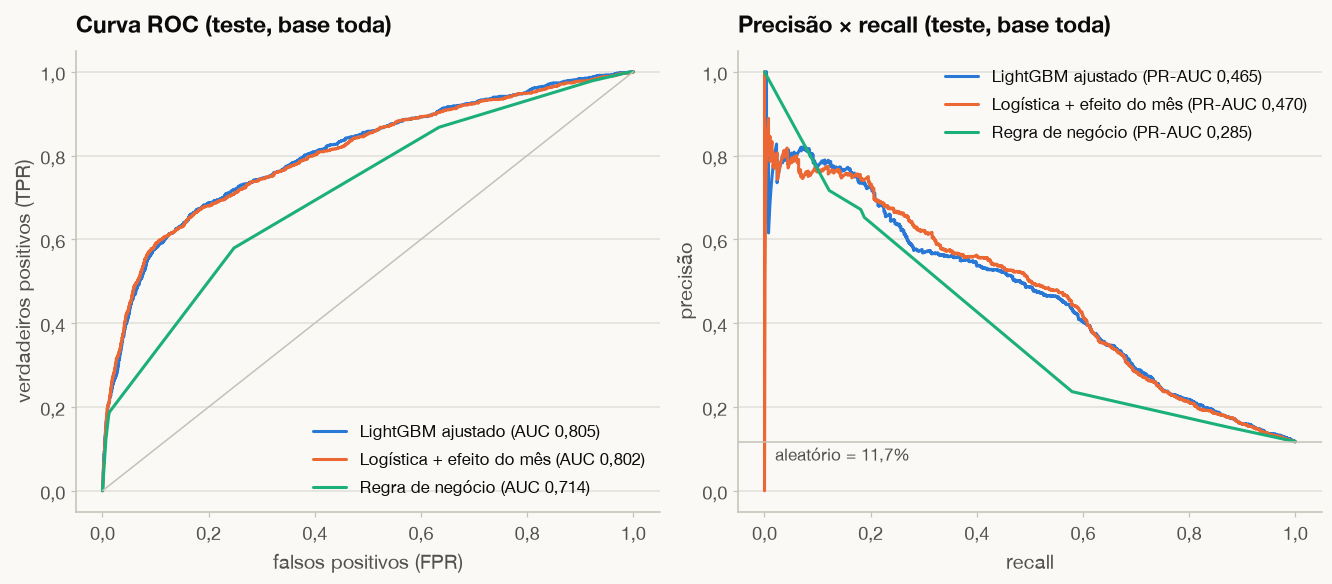

In [17]:
fig, (ax_roc, ax_pr) = plots.new_figure(12, 5.2, ncols=2)
curves = [("LightGBM ajustado", BLUE), ("Logística + efeito do mês", ORANGE), ("Regra de negócio", AQUA)]
for name, color in curves:
    model = fitted[name]
    pooled = model.predict_proba(test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(test)
    fpr, tpr, _ = roc_curve(y_test, pooled)
    prec, rec, _ = precision_recall_curve(y_test, pooled)
    label = f"{name} (AUC {plots.fmt_num(test_table.loc[name, 'roc_auc'], 3)})"
    ax_roc.plot(fpr, tpr, color=color, label=label)
    ax_pr.plot(rec, prec, color=color, label=f"{name} (PR-AUC {plots.fmt_num(test_table.loc[name, 'pr_auc'], 3)})")
ax_roc.plot([0, 1], [0, 1], color=BASELINE, linewidth=1)
ax_pr.axhline(y_test.mean(), color=BASELINE, linewidth=1)
ax_pr.text(0.02, y_test.mean() - 0.045, f"aleatório = {plots.fmt_pct(y_test.mean(), 1)}", ha="left", color=INK_2, fontsize=11)
for ax, xl, yl, title in [(ax_roc, "falsos positivos (FPR)", "verdadeiros positivos (TPR)", "Curva ROC (teste, base toda)"),
                          (ax_pr, "recall", "precisão", "Precisão × recall (teste, base toda)")]:
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    plots.decimal_axis(ax, "x", 1)
    plots.decimal_axis(ax, "y", 1)
    ax.legend(loc="lower right" if ax is ax_roc else "upper right", fontsize=11)
plots.save(fig, "mod_teste_roc_pr")

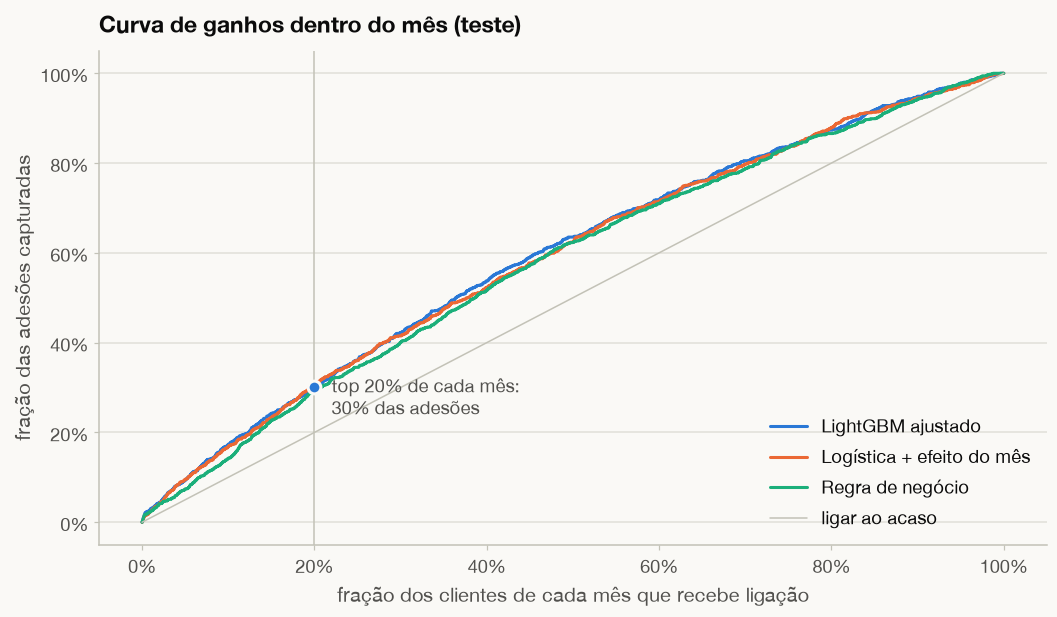

In [18]:
fig, ax = plots.new_figure(9.5, 5.5)
for name, color in curves:
    contacted, captured = gains_curve(y_test, fitted[name].decision_function(test), groups=months)
    ax.plot(contacted, captured, color=color, label=name)
ax.plot([0, 1], [0, 1], color=BASELINE, linewidth=1, label="ligar ao acaso")
lgbm_contacted, lgbm_captured = gains_curve(y_test, lgbm.decision_function(test), groups=months)
at20 = lgbm_captured[np.searchsorted(lgbm_contacted, 0.2)]
ax.axvline(0.2, color=BASELINE, linewidth=1)
ax.scatter([0.2], [at20], color=BLUE, s=70, zorder=3, edgecolor=plots.SURFACE, linewidth=2)
ax.text(0.22, at20 - 0.06, f"top 20% de cada mês:\n{plots.fmt_pct(at20)} das adesões", color=INK_2, fontsize=12)
plots.percent_axis(ax, "x")
plots.percent_axis(ax, "y")
ax.set_xlabel("fração dos clientes de cada mês que recebe ligação")
ax.set_ylabel("fração das adesões capturadas")
ax.set_title("Curva de ganhos dentro do mês (teste)")
ax.legend(loc="lower right")
plots.save(fig, "mod_ganhos_mes")

In [19]:
score_test = pd.Series(lgbm.decision_function(test), index=test.index)
test_pct = score_test.groupby(test[PERIOD]).rank(pct=True, ascending=False, method="first")
decile = np.ceil(test_pct * 10).astype(int)
decile_table = test.assign(decile=decile).groupby("decile")[TARGET].agg(n="size", adesoes="sum", taxa="mean")
decile_table["lift"] = decile_table["taxa"] / y_test.mean()
decile_table["captura_acumulada"] = decile_table["adesoes"].cumsum() / y_test.sum()
decile_table

,n,adesoes,taxa,lift,captura_acumulada
decile,,,,,
1,888,171,0.193,1.646,0.162
2,909,139,0.153,1.307,0.293
3,900,125,0.139,1.187,0.411
4,909,127,0.140,1.194,0.531
5,907,103,0.114,0.971,0.629
6,900,93,0.103,0.883,0.716
7,905,88,0.097,0.831,0.800
8,904,73,0.081,0.690,0.869
9,905,80,0.088,0.756,0.944


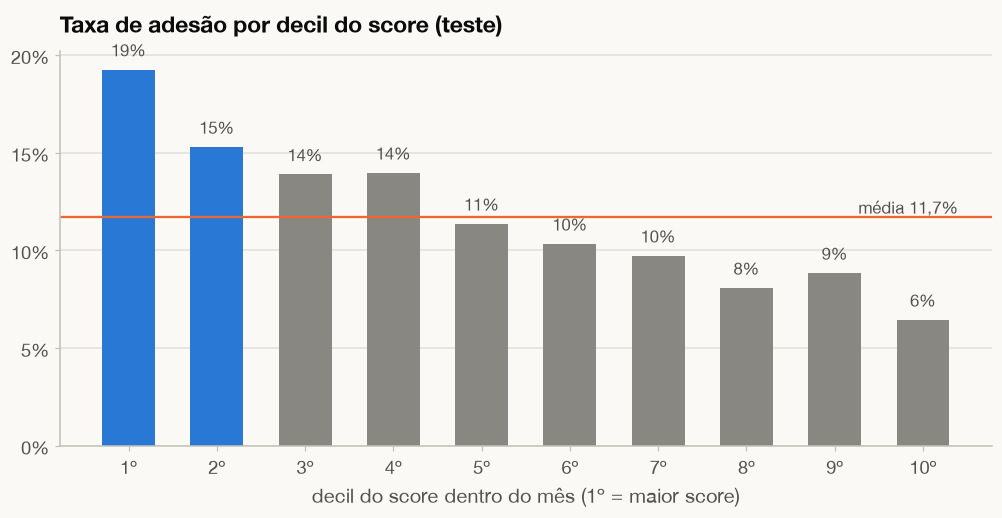

In [20]:
fig, ax = plots.new_figure(9, 4.6)
ax.bar(decile_table.index, decile_table["taxa"], color=[BLUE if d <= 2 else GRAY for d in decile_table.index], width=0.6)
ax.axhline(y_test.mean(), color=ORANGE, linewidth=1.5)
ax.text(10.4, y_test.mean(), f"média {plots.fmt_pct(y_test.mean(), 1)}", va="bottom", ha="right", fontsize=11, color=INK_2)
for d, v in decile_table["taxa"].items():
    ax.text(d, v + 0.005, plots.fmt_pct(v), ha="center", va="bottom", fontsize=11, color=INK_2)
ax.set_xticks(decile_table.index, [f"{d}º" for d in decile_table.index])
ax.set_xlabel("decil do score dentro do mês (1º = maior score)")
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
plots.percent_axis(ax)
ax.set_title("Taxa de adesão por decil do score (teste)")
plots.save(fig, "mod_decis")

**Tradução para o negócio:**
- ligando para os **20% de maior score de cada mês**, o banco captura **~30% das adesões** (contra 20% ao acaso);
- o 1º decil converte **19,3%**, contra 11,7% na média (1,65×), e o último decil **6,4%**;
- a ordenação é quase monotônica: decis 3–4 e 8–9 empatam dentro do ruído.

              precision    recall  f1-score   support

  não aderiu      0.897     0.814     0.853      7985
      aderiu      0.173     0.293     0.217      1058

    accuracy                          0.753      9043
   macro avg      0.535     0.553     0.535      9043
weighted avg      0.812     0.753     0.779      9043



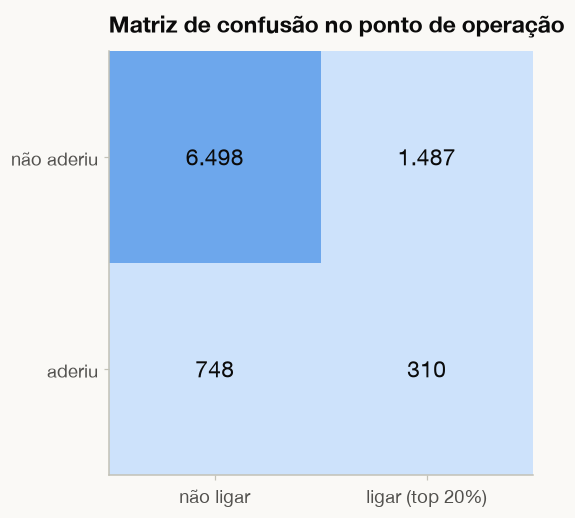

In [21]:
top20 = (test_pct <= 0.2).astype(int)
cm = confusion_matrix(y_test, top20)
print(classification_report(y_test, top20, target_names=["não aderiu", "aderiu"], digits=3))
fig, ax = plots.new_figure(5.6, 4.6)
ax.imshow(cm, cmap=plt.matplotlib.colors.ListedColormap(plots.BLUE_RAMP[:4]), vmin=0, vmax=cm.max() * 1.6)
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, plots.fmt_num(v), ha="center", va="center", fontsize=15, color=plots.INK)
ax.set_xticks([0, 1], ["não ligar", "ligar (top 20%)"])
ax.set_yticks([0, 1], ["não aderiu", "aderiu"])
ax.grid(False)
ax.set_title("Matriz de confusão no ponto de operação")
plots.save(fig, "mod_matriz_confusao")

No ponto de operação top 20%:
- **precisão 17,3%** (vs. 11,7%) e **recall 29,3%**;
- a acurácia desse corte é 75%, **menor** que os 88% de "nunca ligar". É mais um lembrete de que acurácia não
  mede o que importa aqui.

## 8. Ablação: quanto as variáveis proibidas inflariam as métricas

Primeiro, o efeito do ajuste por mês com os mesmos hiperparâmetros. Depois, o LightGBM padrão **sem** o
ajuste, adicionando uma a uma as variáveis que ficaram de fora. É só diagnóstico em CV no treino; nenhuma
dessas variantes é candidata a produção.

In [22]:
ablation_makers = {
    "F0 com ajuste do mês, ajustado (modelo final)": lambda: make_lgbm(**best_params),
    "F0 sem ajuste do mês, mesmos hiperparâmetros": lambda: make_lgbm_pooled(**best_params),
    "F0 com ajuste do mês, padrão": make_lgbm,
    "F0 sem ajuste do mês, padrão": make_lgbm_pooled,
    "F1 = F0 + dia e mês": lambda: make_lgbm_pooled(extra_numeric=["day"], extra_categorical=["month"]),
    "F2 = F1 + campaign": lambda: make_lgbm_pooled(extra_numeric=["day", "campaign"], extra_categorical=["month"]),
    "F3 = F2 + duration (vazamento)": lambda: make_lgbm_pooled(extra_numeric=["day", "campaign", "duration"],
                                                               extra_categorical=["month"]),
}
ablation = pd.DataFrame({name: cross_validate_model(make)[0][["roc_auc", "pr_auc", "group_auc"]].mean()
                         for name, make in ablation_makers.items()}).T
ablation

,roc_auc,pr_auc,group_auc
"F0 com ajuste do mês, ajustado (modelo final)",0.798,0.451,0.617
"F0 sem ajuste do mês, mesmos hiperparâmetros",0.756,0.387,0.607
"F0 com ajuste do mês, padrão",0.793,0.447,0.598
"F0 sem ajuste do mês, padrão",0.750,0.386,0.602
F1 = F0 + dia e mês,0.796,0.446,0.632
F2 = F1 + campaign,0.798,0.448,0.634
F3 = F2 + duration (vazamento),0.937,0.632,0.938


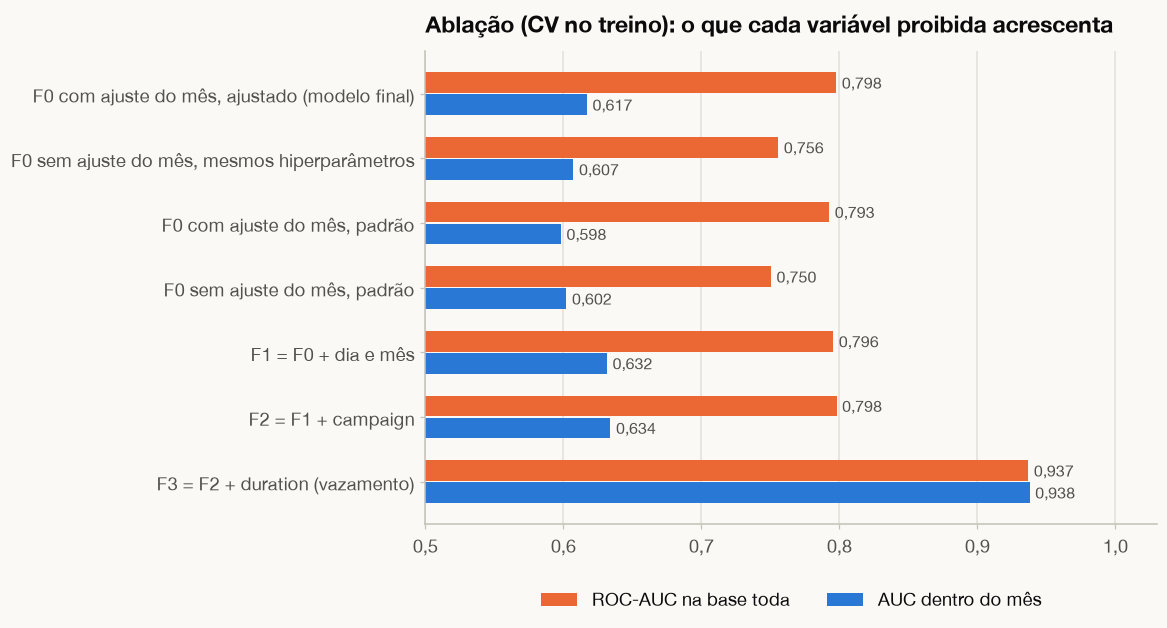

In [23]:
fig, ax = plots.new_figure(10.5, 5.6)
names = list(ablation.index)[::-1]
y_pos = np.arange(len(names))
ax.barh(y_pos + 0.17, ablation.loc[names, "roc_auc"] - 0.5, left=0.5, height=0.32, color=ORANGE, label="ROC-AUC na base toda")
ax.barh(y_pos - 0.17, ablation.loc[names, "group_auc"] - 0.5, left=0.5, height=0.32, color=BLUE, label="AUC dentro do mês")
for yp, name in zip(y_pos, names):
    for offset, col in [(0.17, "roc_auc"), (-0.17, "group_auc")]:
        v = ablation.loc[name, col]
        ax.text(v + 0.004, yp + offset, plots.fmt_num(v, 3), va="center", fontsize=10.5, color=INK_2)
ax.set_yticks(y_pos, names)
ax.set_xlim(0.5, 1.03)
plots.decimal_axis(ax, "x", 1)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_title("Ablação (CV no treino): o que cada variável proibida acrescenta")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
plots.save(fig, "mod_ablacao")

**Leitura da ablação**
- **Com os mesmos hiperparâmetros, o ajuste por mês melhora a ordenação dentro do mês no CV** (0,617 vs. 0,607).
  Esses hiperparâmetros foram ajustados justamente para o modelo com ajuste, e fora do tempo o ganho não se
  confirma (notebook 03). O valor principal do ajuste é outro: a probabilidade se decompõe em clima da
  campanha × cliente, e o modelo deixa de usar idade e profissão como atalho para a época.
- Com hiperparâmetros padrão os dois empatam dentro do mês (~0,60). O ajuste por mês ajuda quando o modelo é
  regularizado o bastante para não aprender ruído.
- **Dia e mês** sobem a AUC dentro do mês para 0,632. Mas `day` é a data do *último* contato, que depende do
  desfecho, e carrega efeitos de calendário da própria campanha. Não é atributo do cliente e não vale para
  ordenar uma lista futura.
- **`campaign`** quase não acrescenta (0,634).
- **`duration`** leva tudo a ~0,94. É o vazamento por trás dos "95%" que circulam em notebooks públicos.

## 9. Modelo final

O modelo final é treinado pelo mesmo código da linha de comando (`python -m bank_marketing.train`). Ele salva
`models/model.joblib` e `models/metadata.json` e registra as métricas de teste em `reports/metrics.json`.

In [24]:
train_main([])
final = json.loads((REPORTS_DIR / "metrics.json").read_text())["final_model"]
assert abs(final["group_auc"] - test_table.loc["LightGBM ajustado", "group_auc"]) < 1e-9  # mesmo modelo, mesmo teste

model saved to models/model.joblib
  group_auc                  0.6062
  lift_at_20_within_month    1.4824
  roc_auc                    0.8047
  ks                         0.4940
  pr_auc                     0.4654


In [25]:
def records(table):
    return {name: {k: float(v) for k, v in row.items()} for name, row in table.iterrows()}


save_metrics("cv", {"best_C": best_C, "c_scores": {str(k): v for k, v in c_scores.items()},
                    "mean": records(cv_table), "std_group_auc": cv_std["group_auc"].to_dict(),
                    "lgbm_minus_logistic_group_auc": {"mean": float(diff.mean()), "se": float(diff.std() / np.sqrt(len(diff))),
                                                       "folds_won": int((diff > 0).sum())}})
save_metrics("tuning", {"best_params": best_params, "best_value": float(trials["value"].max()), "n_trials": int(len(trials))})
save_metrics("test", {"models": records(test_table), "bootstrap": boot,
                      "top20_capture_within_month": float(at20),
                      "deciles": {int(d): {"rate": float(r["taxa"]), "lift": float(r["lift"]),
                                           "cum_capture": float(r["captura_acumulada"])} for d, r in decile_table.iterrows()},
                      "confusion_matrix_top20": cm.tolist()})
save_metrics("operating_point", {"assumptions": {"C_client": C_CLIENT, "V_subscription": V_SUBSCRIPTION},
                                 "oof_calibration_max_gap": float(calib_gap), "rules": records(op_table),
                                 "by_year": {str(k): {kk: float(vv) for kk, vv in v.items()} for k, v in ev_by_year.items()},
                                 "sensitivity": records(pd.DataFrame(sensitivity).T)})
save_metrics("ablation", records(ablation))
print("seções cv, tuning, test, operating_point e ablation salvas em reports/metrics.json")

seções cv, tuning, test, operating_point e ablation salvas em reports/metrics.json
